# NB_01 — Build Vector Store

This notebook constructs the retrieval index used by all six agent architectures. Raw PDFs are extracted to Markdown with a vision-capable LLM, split into overlapping chunks by a two-stage header-aware splitter, embedded with `text-embedding-3-large`, and upserted into a Qdrant flat collection with keyword payload indexes for filtered retrieval.

## Section overview

0. **Configuration** — load `AppConfig` and log pipeline parameters
1. **Extract PDFs to Markdown** — rasterise each page and convert to structured Markdown
2. **Chunk Markdown documents** — two-stage header-aware + recursive character split
3. **Chunk distribution analysis** — visualize size, company, and category distributions
4. **Index chunks into Qdrant Vector Store** — embed and upsert in batches
5. **Verify vector store** — smoke-test global and file-scoped retrieval

## Splitting strategy

| Stage | Method | Parameters |
|---|---|---|
| 1 — Header-aware split | `MarkdownHeaderTextSplitter` | Splits on `#`, `##`, `###`; header path preserved as metadata |
| 2 — Recursive character split | `RecursiveCharacterTextSplitter` | IPID: 384 chars / 48 overlap; OWU: 512 chars / 64 overlap |

## Prerequisites

- Qdrant running: `docker compose up -d qdrant`
- Raw PDF documents in `data/raw_documents/`
- OpenAI API key in `.env`

Run cells from top to bottom.

In [40]:
import sys
from pathlib import Path

# Ensure project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Step 0: Configuration

Loads `AppConfig` and logs the key pipeline parameters — paths, model names, chunking settings, and Qdrant coordinates — so every run is self-documenting.

In [41]:
import logging
import warnings

warnings.filterwarnings("ignore")

import structlog

structlog.configure(
    wrapper_class=structlog.make_filtering_bound_logger(logging.INFO),
)
logger = structlog.get_logger(__name__)

from sources.config import config as app_config, DocumentType

logger.info(
    "pipeline_config",
    raw_documents=str(app_config.paths.raw_documents_dir),
    extracted_documents=str(app_config.paths.extracted_documents_dir),
    llm_model=app_config.llm.model_name,
    llm_max_concurrent=app_config.llm.max_concurrent_api_calls,
    llm_retry_attempts=app_config.llm.retry_max_attempts,
    llm_cross_page_context=app_config.llm.enable_cross_page_context,
    embedding_model=app_config.embedding.model_name,
    embedding_dimension=app_config.embedding.embedding_dimension,
    qdrant=f"{app_config.qdrant.host}:{app_config.qdrant.port}",
    qdrant_collection=app_config.qdrant.collection_name,
    max_workers=app_config.concurrency.max_workers,
    ipid_chunking=f"size={app_config.chunking_ipid.chunk_size}, overlap={app_config.chunking_ipid.chunk_overlap}, min={app_config.chunking_ipid.min_chunk_size}",
    owu_chunking=f"size={app_config.chunking_owu.chunk_size}, overlap={app_config.chunking_owu.chunk_overlap}, min={app_config.chunking_owu.min_chunk_size}",
)

2026-05-16 18:08:46 [info     ] pipeline_config                embedding_dimension=3072 embedding_model=text-embedding-3-large extracted_documents=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/extracted_documents ipid_chunking='size=384, overlap=48, min=48' llm_cross_page_context=True llm_max_concurrent=16 llm_model=gpt-5 llm_retry_attempts=5 max_workers=32 owu_chunking='size=512, overlap=64, min=64' qdrant=localhost:6333 qdrant_collection=insurance_documents raw_documents=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/raw_documents


## Step 1: Extract PDFs to Markdown

Extract text from all PDF documents using a vision-capable LLM (OpenAI GPT-4o).
Each page is rendered as an image and converted to structured Markdown.

In [42]:
from sources.extractor import Extractor

extractor = Extractor()
logger.info("extractor_initialized")

2026-05-16 18:08:47 [info     ] extractor_initialized         


In [43]:
# Extract only missing IPID documents
ipid_raw_folder = app_config.paths.raw_documents_dir / "ipid"
ipid_extracted_folder = app_config.paths.extracted_documents_dir / "ipid"

if ipid_raw_folder.exists():
    pdf_files = sorted(ipid_raw_folder.rglob("*.pdf"))

    existing_md = set()
    if ipid_extracted_folder.exists():
        existing_md = {md.stem for md in ipid_extracted_folder.rglob("*.md")}

    pdfs_to_extract = [pdf for pdf in pdf_files if pdf.stem not in existing_md]

    if pdfs_to_extract:
        logger.info(
            "ipid_extraction_start",
            to_extract=len(pdfs_to_extract),
            total=len(pdf_files),
            folder=str(ipid_raw_folder),
        )
        extracted_ipid = extractor.extract_files(pdfs_to_extract)
        logger.info("ipid_extraction_complete", extracted=len(extracted_ipid))
    else:
        logger.info("ipid_already_extracted", total=len(pdf_files))
        extracted_ipid = (
            sorted(ipid_extracted_folder.rglob("*.md"))
            if ipid_extracted_folder.exists()
            else []
        )
else:
    logger.warning("ipid_folder_not_found", folder=str(ipid_raw_folder))
    extracted_ipid = []

2026-05-16 18:08:48 [info     ] ipid_already_extracted         total=11


In [44]:
# Extract only missing OWU documents
owu_raw_folder = app_config.paths.raw_documents_dir / "owu"
owu_extracted_folder = app_config.paths.extracted_documents_dir / "owu"

if owu_raw_folder.exists():
    pdf_files = sorted(owu_raw_folder.rglob("*.pdf"))

    existing_md = set()
    if owu_extracted_folder.exists():
        existing_md = {md.stem for md in owu_extracted_folder.rglob("*.md")}

    pdfs_to_extract = [pdf for pdf in pdf_files if pdf.stem not in existing_md]

    if pdfs_to_extract:
        logger.info(
            "owu_extraction_start",
            to_extract=len(pdfs_to_extract),
            total=len(pdf_files),
            folder=str(owu_raw_folder),
        )
        extracted_owu = extractor.extract_files(pdfs_to_extract)
        logger.info("owu_extraction_complete", extracted=len(extracted_owu))
    else:
        logger.info("owu_already_extracted", total=len(pdf_files))
        extracted_owu = (
            sorted(owu_extracted_folder.rglob("*.md"))
            if owu_extracted_folder.exists()
            else []
        )
else:
    logger.warning("owu_folder_not_found", folder=str(owu_raw_folder))
    extracted_owu = []

2026-05-16 18:08:48 [info     ] owu_already_extracted          total=11


In [45]:
# Summary of extraction
total_extracted = len(extracted_ipid) + len(extracted_owu)
logger.info(
    "extraction_summary",
    ipid=len(extracted_ipid),
    owu=len(extracted_owu),
    total=total_extracted,
)

2026-05-16 18:08:48 [info     ] extraction_summary             ipid=11 owu=11 total=22


## Step 2: Chunk Markdown Documents

Each extracted Markdown file is split first by header hierarchy (`#`, `##`, `###`) to keep related clauses together, then recursively by character count with document-type-specific parameters. The resulting chunks are the units stored and retrieved in Qdrant.

In [46]:
from sources.chuncker import Chuncker

chunker = Chuncker()
logger.info("chuncker_initialized")

2026-05-16 18:08:49 [info     ] chuncker_initialized          


In [47]:
# Chunk all IPID documents
ipid_folder = app_config.paths.extracted_documents_dir / "ipid"

if ipid_folder.exists():
    logger.info("chunking_ipid", folder=str(ipid_folder))
    ipid_chunks = chunker.chunk_folder(ipid_folder, DocumentType.IPID)
    logger.info("ipid_chunks_created", total=len(ipid_chunks))
else:
    logger.warning("ipid_folder_not_found", folder=str(ipid_folder))
    ipid_chunks = []

2026-05-16 18:08:49 [info     ] chunking_ipid                  folder=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/extracted_documents/ipid
2026-05-16 18:08:49 [info     ] markdown_files_found           count=11 folder=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/extracted_documents/ipid


Chunking files:   0%|          | 0/11 [00:00<?, ?file/s]

2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=warta_autocasco_standard_acs.md
2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=warta_warta_dom.md
2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=hestia_ergo7_pozakomunikacyjne.md
2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=pzu_pzu_dom.md
2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=warta_autocasco_komfort_ack.md
2026-05-16 18:08:52 [info     ] chunks_generated               file=warta_warta_dom.md total=33
2026-05-16 18:08:52 [info     ] chunking_file                  document_type=ipid file=hestia_ergo7_komunikacja.md
2026-05-16 18:08:52 [info     ] chunks_generated               file=warta_autocasco_standard_acs.md total=22
2026-05-16 18:08:52 [info     ] chunks_generated               file=hestia_ergo7_pozakomunikacyjne.md total=71
202

In [48]:
# Chunk all OWU documents
owu_folder = app_config.paths.extracted_documents_dir / "owu"

if owu_folder.exists():
    logger.info("chunking_owu", folder=str(owu_folder))
    owu_chunks = chunker.chunk_folder(owu_folder, DocumentType.OWU)
    logger.info("owu_chunks_created", total=len(owu_chunks))
else:
    logger.warning("owu_folder_not_found", folder=str(owu_folder))
    owu_chunks = []

2026-05-16 18:08:53 [info     ] chunking_owu                   folder=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/extracted_documents/owu
2026-05-16 18:08:53 [info     ] markdown_files_found           count=11 folder=/Users/mchojna/Documents/Repozytoria/master-thesis/code/data/documents/extracted_documents/owu


Chunking files:   0%|          | 0/11 [00:00<?, ?file/s]

2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=hestia_ergo7_komunikacja.md
2026-05-16 18:08:56 [info     ] chunks_generated               file=hestia_ergo7_komunikacja.md total=393
2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=pzu_pzu_auto.md
2026-05-16 18:08:56 [info     ] chunks_generated               file=pzu_pzu_auto.md total=660
2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=warta_autocasco_komfort_ack.md
2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=pzu_pzu_dom.md
2026-05-16 18:08:56 [info     ] chunks_generated               file=warta_autocasco_komfort_ack.md total=127
2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=warta_owu_warta_dom.md
2026-05-16 18:08:56 [info     ] chunking_file                  document_type=owu file=warta_autocasco_standard_acs.md
2026-05-16 18:08:56 [info     

In [49]:
import collections

# Combine all chunks
all_chunks = ipid_chunks + owu_chunks

chunk_sizes = [len(c.content) for c in all_chunks]
logger.info(
    "chunking_summary",
    total=len(all_chunks),
    chunk_min=min(chunk_sizes) if chunk_sizes else 0,
    chunk_max=max(chunk_sizes) if chunk_sizes else 0,
    chunk_avg=round(sum(chunk_sizes) / len(chunk_sizes)) if chunk_sizes else 0,
    ipid=len(ipid_chunks),
    owu=len(owu_chunks),
)

# Verification table: chunks per document type
by_type = collections.Counter(c.metadata.document_type for c in all_chunks)
by_company = collections.Counter(c.metadata.company_name for c in all_chunks)
by_product_cat = collections.Counter(c.metadata.product_category for c in all_chunks)

print("\nChunks per document type:")
for dtype, count in sorted(by_type.items()):
    print(f"  {dtype:6s}  {count:5d}")

print("\nChunks per company:")
for company, count in sorted(by_company.items()):
    print(f"  {company:10s}  {count:5d}")

print("\nChunks per product category:")
for cat, count in sorted(by_product_cat.items()):
    print(f"  {cat:20s}  {count:5d}")

2026-05-16 18:08:56 [info     ] chunking_summary               chunk_avg=363 chunk_max=512 chunk_min=52 ipid=542 owu=4566 total=5108

Chunks per document type:
  ipid      542
  owu      4566

Chunks per company:
  hestia       1395
  pzu          2334
  warta        1379

Chunks per product category:
  auto                   1478
  mieszkanie             2300
  podroze                1330


## Step 3: Chunk distribution analysis

The plots below show chunk size distribution by document type and the share of chunks per company and product category. IPID chunks are shorter (concise summary tables); OWU chunks approach the configured maximum of 512 characters.

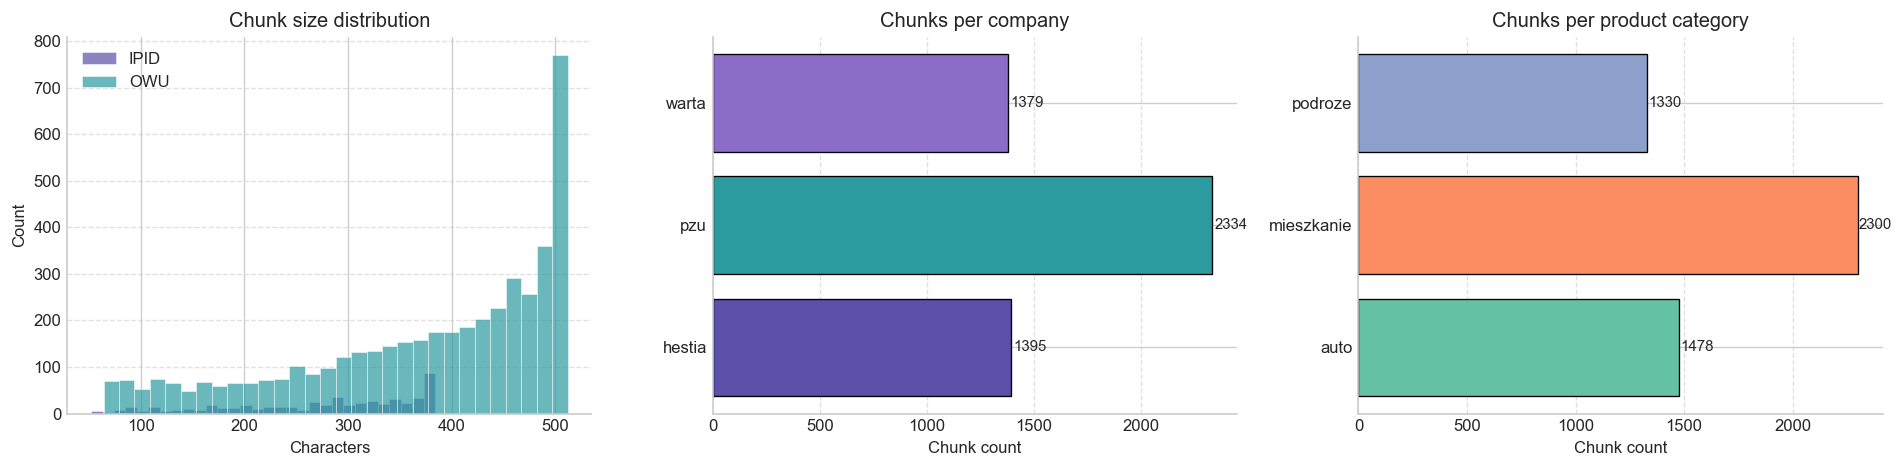

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.style as mstyle
import seaborn as sns

mstyle.use("seaborn-v0_8-whitegrid")

ARCH_COLORS = {
    "deterministic": "#5B4FA8",
    "planner_executor": "#2B9BA0",
    "router_specialist": "#8B6DC8",
    "blackboard": "#C07840",
    "hierarchical": "#3A7DB5",
    "react": "#A84848",
}
COLOR_IPID = "#5B4FA8"
COLOR_OWU = "#2B9BA0"
COMPANY_COLORS = ["#5B4FA8", "#2B9BA0", "#8B6DC8"]

ipid_sizes = [len(c.content) for c in ipid_chunks]
owu_sizes = [len(c.content) for c in owu_chunks]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

# Chunk size distribution
axes[0].hist(
    ipid_sizes,
    bins=30,
    alpha=0.7,
    label="IPID",
    color=COLOR_IPID,
    edgecolor="white",
    linewidth=0.4,
)
axes[0].hist(
    owu_sizes,
    bins=30,
    alpha=0.7,
    label="OWU",
    color=COLOR_OWU,
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_title("Chunk size distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
axes[0].set_axisbelow(True)
sns.despine(ax=axes[0])

# Chunks per company
companies = sorted(by_company.keys())
company_counts = [by_company[c] for c in companies]
axes[1].barh(
    companies,
    company_counts,
    color=COMPANY_COLORS[: len(companies)],
    edgecolor="black",
    linewidth=0.8,
)
axes[1].set_title("Chunks per company")
axes[1].set_xlabel("Chunk count")
for i, v in enumerate(company_counts):
    axes[1].text(v + 10, i, str(v), va="center", fontsize=9)
axes[1].grid(axis="x", linestyle="--", alpha=0.6, zorder=0)
axes[1].set_axisbelow(True)
sns.despine(ax=axes[1])

# Chunks per product category
categories = sorted(by_product_cat.keys())
cat_counts = [by_product_cat[c] for c in categories]
colors = plt.cm.Set2.colors[: len(categories)]
axes[2].barh(categories, cat_counts, color=colors, edgecolor="black", linewidth=0.8)
axes[2].set_title("Chunks per product category")
axes[2].set_xlabel("Chunk count")
for i, v in enumerate(cat_counts):
    axes[2].text(v + 5, i, str(v), va="center", fontsize=9)
axes[2].grid(axis="x", linestyle="--", alpha=0.6, zorder=0)
axes[2].set_axisbelow(True)
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

## Step 4: Index Chunks into Qdrant Vector Store

Embeds all chunks with `text-embedding-3-large` and upserts them into the Qdrant collection in batches. Skips re-indexing if the collection already contains the expected number of points.

In [51]:
from sources.vectorstore import VectorStore

retriever = VectorStore()
logger.info(
    "retriever_initialized",
    qdrant=f"{app_config.qdrant.host}:{app_config.qdrant.port}",
    collection=app_config.qdrant.collection_name,
)

2026-05-16 18:08:57 [info     ] qdrant_connected               collections=1
2026-05-16 18:08:57 [info     ] collection_exists              collection=insurance_documents
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=source_file
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=document_type
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=company_name
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=product_name
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=product_category
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=header_1
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=header_2
2026-05-16 18:08:57 [info     ] payload_index_ensured          field=header_3
2026-05-16 18:08:57 [info     ] retriever_initialized          collection=insurance_documents qdrant=localhost:6333


In [ ]:
# Skip indexing if the collection already contains the expected number of chunks.
# index_chunks is not idempotent by default, so re-running would duplicate vectors.
from qdrant_client import QdrantClient as _QdrantClient

_qd = _QdrantClient(host=app_config.qdrant.host, port=app_config.qdrant.port)
_current_points = int(
    _qd.get_collection(app_config.qdrant.collection_name).points_count or 0
)

if _current_points >= len(all_chunks):
    logger.info(
        "indexing_skipped_collection_already_populated",
        existing_points=_current_points,
        expected=len(all_chunks),
    )
else:
    logger.info(
        "indexing_start", chunks=len(all_chunks), existing_points=_current_points
    )
    retriever.index_chunks(all_chunks)
    logger.info("indexing_complete")

## Step 5: Verify Vector Store

Runs two smoke-test queries — one global and one file-scoped — to confirm that embedding, filtering, and scoring all work end-to-end before moving to NB_02.

In [ ]:
# Test semantic search
test_query = "Co obejmuje ubezpieczenie?"
results = retriever.retrieve_context(test_query, top_k=3)

logger.info("test_query", query=test_query, results=len(results))

for i, result in enumerate(results, 1):
    logger.info(
        "result",
        rank=i,
        score=round(result.score, 4),
        source=result.chunk.metadata.source_file,
        company=result.chunk.metadata.company_name,
        product=result.chunk.metadata.product_name,
        category=result.chunk.metadata.product_category,
        header_1=result.chunk.metadata.header_1,
        header_2=result.chunk.metadata.header_2,
        content_preview=result.chunk.content[:250],
    )

In [ ]:
# Test file-scoped retrieval
test_query = "Jakie są wyłączenia odpowiedzialności?"
test_file = "pzu_pzu_auto.md"
results = retriever.retrieve_from_file(test_query, test_file, top_k=3)

logger.info("test_file_query", query=test_query, file=test_file, results=len(results))

for i, result in enumerate(results, 1):
    logger.info(
        "result",
        rank=i,
        score=round(result.score, 4),
        header_1=result.chunk.metadata.header_1,
        header_2=result.chunk.metadata.header_2,
        content_preview=result.chunk.content[:250],
    )

In [ ]:
# Verify retrieved chunk metadata in flat index mode
if results:
    sample = results[0]
    logger.info(
        "retrieved_chunk",
        length=len(sample.chunk.content),
        content_preview=sample.chunk.content[:300],
        source=sample.chunk.metadata.source_file,
        company=sample.chunk.metadata.company_name,
        product=sample.chunk.metadata.product_name,
        category=sample.chunk.metadata.product_category,
    )
else:
    logger.warning("no_results_for_metadata_check")